In [74]:
import os
os.getcwd()
os.chdir("/Users/xiaolingsundberg/Desktop/Other Data Analysis Projects (for fun)/CovidOnLottery/Data")

In [75]:
# read in stata data useing pd.read_stata() 
import pandas as pd
df = pd.read_stata("powerball_revenues_fl.dta")

# A quick peek

In [76]:
# print the first 5 rows
print(df.head())

   draw_date  revenues  jackpot  covid  covid_cases  monday  wednesday  \
0 2016-05-04   7808170      348      0            0       0          1   
1 2016-05-07  13609322      415      0            0       0          0   
2 2016-05-11   2767830       40      0            0       0          1   
3 2016-05-14   3165299       50      0            0       0          0   
4 2016-05-18   2707620       60      0            0       0          1   

   unempr_adjusted  unempr  jan  ...  sept  oct  nov  year2016  year2017  \
0              4.9     4.6    0  ...     0    0    0         1         0   
1              4.9     4.6    0  ...     0    0    0         1         0   
2              4.9     4.6    0  ...     0    0    0         1         0   
3              4.9     4.6    0  ...     0    0    0         1         0   
4              4.9     4.6    0  ...     0    0    0         1         0   

   year2018  year2019  year2020  year2021  year2022  
0         0         0         0         0   

In [77]:
# check number of rows and columns
print(df.shape)

(639, 27)


In [78]:
# check column names
print(df.columns)

Index(['draw_date', 'revenues', 'jackpot', 'covid', 'covid_cases', 'monday',
       'wednesday', 'unempr_adjusted', 'unempr', 'jan', 'feb', 'mar', 'apr',
       'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov', 'year2016',
       'year2017', 'year2018', 'year2019', 'year2020', 'year2021', 'year2022'],
      dtype='object')


In [79]:
# print the last 5 rows
print(df.tail())

     draw_date  revenues  jackpot  covid  covid_cases  monday  wednesday  \
634 2022-02-26   2811939       58      1         1359       0          0   
635 2022-02-28   1503676       65      1         2155       1          0   
636 2022-03-02   1978610       73      1         2333       0          1   
637 2022-03-05   2884397       85      1         1531       0          0   
638 2022-03-07   1544416       90      1         1600       1          0   

     unempr_adjusted  unempr  jan  ...  sept  oct  nov  year2016  year2017  \
634              3.3     3.1    0  ...     0    0    0         0         0   
635              3.3     3.1    0  ...     0    0    0         0         0   
636              3.2     2.7    0  ...     0    0    0         0         0   
637              3.2     2.7    0  ...     0    0    0         0         0   
638              3.2     2.7    0  ...     0    0    0         0         0   

     year2018  year2019  year2020  year2021  year2022  
634         0     

In [80]:
# check variable data types
print(df.dtypes)

draw_date          datetime64[ns]
revenues                    int32
jackpot                     int16
covid                        int8
covid_cases                 int32
monday                       int8
wednesday                    int8
unempr_adjusted           float64
unempr                    float64
jan                          int8
feb                          int8
mar                          int8
apr                          int8
may                          int8
jun                          int8
jul                          int8
aug                          int8
sept                         int8
oct                          int8
nov                          int8
year2016                     int8
year2017                     int8
year2018                     int8
year2019                     int8
year2020                     int8
year2021                     int8
year2022                     int8
dtype: object


In [81]:
# check missing values
print(df.isnull().sum())

draw_date          0
revenues           0
jackpot            0
covid              0
covid_cases        0
monday             0
wednesday          0
unempr_adjusted    0
unempr             0
jan                0
feb                0
mar                0
apr                0
may                0
jun                0
jul                0
aug                0
sept               0
oct                0
nov                0
year2016           0
year2017           0
year2018           0
year2019           0
year2020           0
year2021           0
year2022           0
dtype: int64


# Data Exploration
## Summary Statistics and Visualization

In [82]:
# summary statistics - numerical 
print(df.describe())

                           draw_date      revenues     jackpot       covid  \
count                            639  6.390000e+02  639.000000  639.000000   
mean   2019-05-18 11:49:51.549295872  3.818770e+06  168.948357    0.374022   
min              2016-05-04 00:00:00  1.439134e+06   20.000000    0.000000   
25%              2017-11-13 00:00:00  2.568074e+06   70.000000    0.000000   
50%              2019-05-25 00:00:00  3.082460e+06  130.000000    0.000000   
75%              2020-12-03 12:00:00  3.768981e+06  229.000000    1.000000   
max              2022-03-07 00:00:00  3.812189e+07  750.000000    1.000000   
std                              NaN  3.040242e+06  132.861274    0.484248   

        covid_cases      monday   wednesday  unempr_adjusted      unempr  \
count    639.000000  639.000000  639.000000       639.000000  639.000000   
mean    3197.406886    0.043818    0.474178         4.733959    4.718936   
min        0.000000    0.000000    0.000000         2.700000    2.500

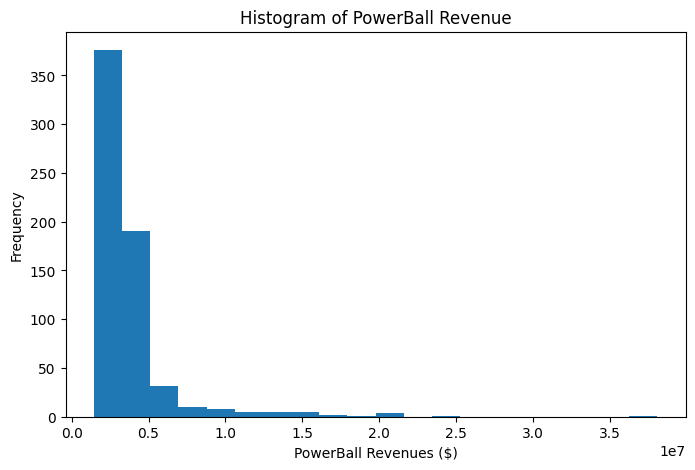

In [83]:
# histogram - show revenue distribution 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["revenues"],bins=20)
plt.xlabel("PowerBall Revenues ($)")
plt.ylabel("Frequency")
plt.title("Histogram of PowerBall Revenue")
plt.show()


Conclusion: The revenues distribution is heavily right-skewed with most observations concentrated in the lower revenue range roughly between $2.5 million and $5.0 million and there are a few much larger values that create a long right tail. A log transformation may be considered.

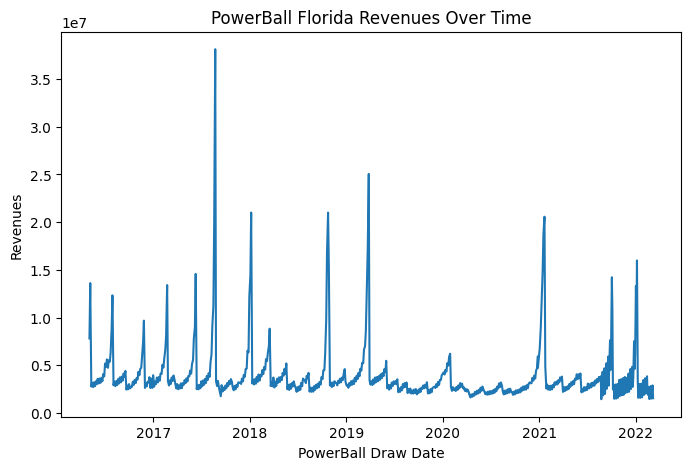

In [84]:
# line plot - show how revenues change over time 
plt.figure(figsize=(8,5))
plt.plot(df["draw_date"],df["revenues"])
plt.xlabel("PowerBall Draw Date")
plt.ylabel("Revenues")
plt.title("PowerBall Florida Revenues Over Time")
plt.show()

Conclusion: The line plot shows a clear decline in PowerBall revenues during the Covid period, particularly in 2020, before recovery afterward. There seems to be a revenue outlier in late 2017 exceeding $35 million.

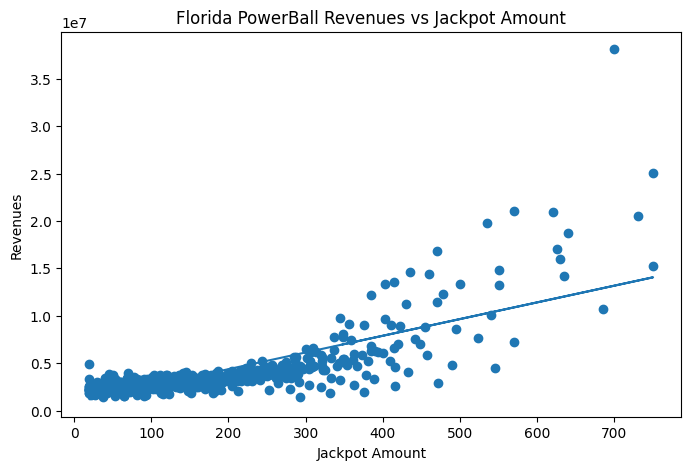

In [85]:
# scatter plot - show how revenues changes as the amount of jackpot changes
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot"],df["revenues"])

m,b = np.polyfit(df["jackpot"], df["revenues"],1)
plt.plot(df["jackpot"], m*df["jackpot"]+b)

plt.xlabel("Jackpot Amount")
plt.ylabel("Revenues")
plt.title("Florida PowerBall Revenues vs Jackpot Amount")
plt.show()

Conclusion: The scatter plot suggests a positive association between the jackpot amount and revenues: as the jackpot amount increases, revenues tend to increase. The relation is roughly linear, although as the jackpot amount gets larger, the range of the revenues spreads wider, suggesting that variability increases at higher jackpot amounts. There is one extremely large revenue outlier over $30 million associated with a jackpot close to $700 million.

In [86]:
# compare revenues between Pre-covid and Covid periods 
# define Covid period: any time after March 03, 2020 (first case recorded in the United States)
df["covid_period"] = np.where(
    df["draw_date"] >= pd.Timestamp("2020-03-04"),
    1,
    0
)

<Figure size 800x500 with 0 Axes>

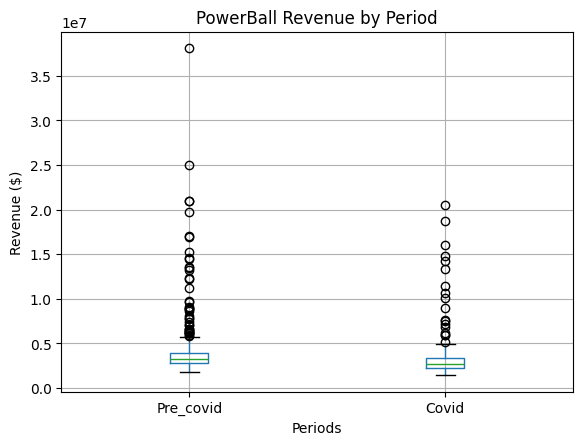

In [ ]:
# boxplot 
# define a new variable "covid_label" - using map() -  covid_period =0 as "Pre_covid" and =1 as "Covid"
# pre_covid: May 04,2016 - March 03,2020; covid: March 04,2020 - March 07, 2022 
# May 04, 2016 is the earliest date lottery information could be found online and March 07 is the day this project began.
df["covid_label"] = pd.Categorical(
    df["covid_period"].map({0:"Pre_covid", 1:"Covid"}),
    categories=["Pre_covid", "Covid"],
    ordered=True
) # used pd.Categorical() to treat "covid_label" as categorical and not ordinal; ordered=True ensures Pre_covid is in front of Covid

plt.figure(figsize=(8,5))
df.boxplot(column = "revenues", by="covid_label")

plt.title("PowerBall Revenue by Period")
plt.suptitle("") # to clean the auto title 
plt.xlabel("Periods")
plt.ylabel("Revenue ($)")
plt.show()


Conclusion: The boxplot shows a fairly similar PowerBall median revenue for both Pre_covid and Covid periods with the Pre_covid period slightly higher. The graph also shows that both periods have high revenue outliers. There is one extremely large revenue outlier in the Pre_covid period. This may be related to a very large jackpot, and can be further examined. 

In [100]:
# correlation coefficient tests
# Pearson's p and Spearman Rank Order Correlation 
print("Pearson's Correlation:")
print(df[["jackpot","revenues"]].corr(method="pearson"))

print("Spearman's Correlation:")
print(df[["jackpot","revenues"]].corr(method="spearman"))

Pearson's Correlation:
           jackpot  revenues
jackpot   1.000000  0.770158
revenues  0.770158  1.000000
Spearman's Correlation:
           jackpot  revenues
jackpot   1.000000  0.754274
revenues  0.754274  1.000000


Both the Pearson and Spearman correlations show a strong positive association between revenues and jackpot amount, suggesting that the positive relationship is stable, even though the data still show skewness and outliers.

# Outlier Detection for Revenues
### 3 standard deviation rule 
### Hampel Identifier
### IQR - already done above

In [106]:
# 3 standard deviation rule 
mean_revenue = df["revenues"].mean()
std_revenue = df["revenues"].std()

lower_3std = mean_revenue - 3*std_revenue
upper_3std = mean_revenue + 3*std_revenue

outliers_std = df[(df["revenues"]<lower_3std)|(df["revenues"]>upper_3std)]

print("3 Standard Deviation Rule:")
print("Lower Bound:", lower_3std)
print("Upper Bound:", upper_3std)
print("Number of Outliers", outliers_std.shape[0])

print(outliers_std[["draw_date","jackpot","revenues"]])

3 Standard Deviation Rule:
Lower Bound: -5301954.524133937
Upper Bound: 12939495.2252294
Number of Outliers 19
     draw_date  jackpot  revenues
1   2016-05-07      415  13609322
84  2017-02-22      403  13402222
115 2017-06-10      435  14571695
135 2017-08-19      535  19784137
136 2017-08-23      700  38121888
174 2018-01-03      460  14426212
175 2018-01-06      570  21000850
257 2018-10-20      470  16881580
258 2018-10-24      620  20998301
259 2018-10-27      750  15218359
300 2019-03-20      550  13206588
301 2019-03-23      625  17092799
302 2019-03-27      750  25053314
490 2021-01-13      550  14818294
491 2021-01-16      640  18767788
492 2021-01-20      730  20568410
571 2021-10-02      635  14220380
610 2022-01-01      500  13299894
612 2022-01-05      630  15981253


Note: 19 rows of outliers are detected. Since the outlier proportion is about 3% (above the 1% 3std rule threshold), a Hampel comparison is considered.

In [116]:
# hampel identifier 
    ## the hampel use median and MAD is the core part
# MAD:
    ## first calculate the absolute deviation: abs(revenues - median_revenue)
    ## then take the median of those absolute deviations

# Hampel score:
    ## absolute deviation divided by (1.4826 * MAD)
median_revenue = df["revenues"].median()

MAD = np.median(np.abs(df["revenues"]-median_revenue))

hampel_score = np.abs(df["revenues"]-median_revenue)/1.4826*MAD

outliers_hampel = df[hampel_score>3]

print("Hample Outliers:")
print("Median:", median_revenue)
print("MAD:", MAD)
print("Number of Outliers:", outliers_hampel.shape[0])

print(outliers_hampel[["draw_date","jackpot","revenues"]])

Hample Outliers:
Median: 3082460.0
MAD: 578479.0
Number of Outliers: 638
     draw_date  jackpot  revenues
0   2016-05-04      348   7808170
1   2016-05-07      415  13609322
2   2016-05-11       40   2767830
3   2016-05-14       50   3165299
4   2016-05-18       60   2707620
..         ...      ...       ...
634 2022-02-26       58   2811939
635 2022-02-28       65   1503676
636 2022-03-02       73   1978610
637 2022-03-05       85   2884397
638 2022-03-07       90   1544416

[638 rows x 3 columns]
